# Cross-over levelling: trend vs wavelength based

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This notebook uses the data and intersections dataframes from the previous notebook `Cross-over-errors`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
    ]
]

# define flight lines vs tie lines
data_df["line_type"] = np.where(data_df.line >= 142, 1, 0)

data_df = data_df.rename(columns={"distance_along_line": "along_line_distance"})

# keep a subset of tie lines and just 1 flight line
line = 77
lines_to_keep = [
    150,
    151,
    152,
    153,
    154,
    155,
    156,
    157,
    158,
    159,
    160,
    161,
    162,
    164,
    165,
    166,
    167,
]
lines_to_keep = np.append(lines_to_keep, line)

data_df = data_df[(data_df.line.isin(lines_to_keep))]

data_df.head()

,easting,northing,height,line,unixtime,along_line_distance,mag,line_type
155245,613796.184341,108259.149034,3793.1,77,1.230970e+09,72.986528,35.54,0
155246,614014.105815,108288.966298,3791.7,77,1.230970e+09,292.943124,35.18,0
155247,614232.757811,108315.269624,3791.9,77,1.230970e+09,513.172378,34.43,0
155248,614414.514181,108337.253486,3793.5,77,1.230970e+09,696.255616,33.60,0
155249,614594.969358,108363.481597,3794.7,77,1.230970e+09,878.614978,32.61,0


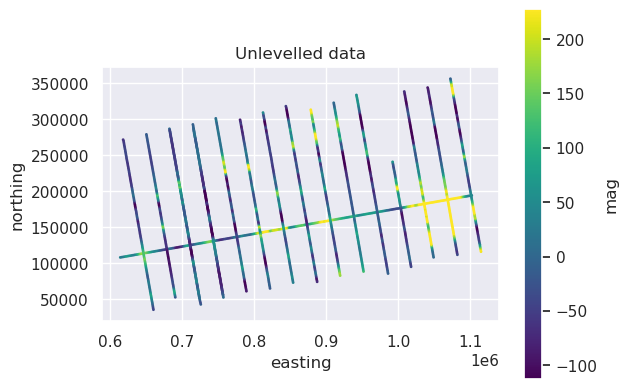

In [3]:
vmin, vmax = vd.minmax(data_df.mag, min_percentile=5, max_percentile=95)
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=1,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    title="Unlevelled data",
)
ax.set_aspect("equal")

In [ ]:
# Create Survey object with data and column bindings
survey = airbornegeo.Survey(
    data_df,
    line_column="line",
    line_type_column="line_type",
    distance_column="along_line_distance",
)

# calculate theoretical intersection points
survey.create_intersection_table(method="groups")

# interpolate mag data at intersections
survey.interpolate_intersections(
    to_interp="mag",
    window_width=500,
    method="cubic",
    extrapolate=False,
)

# calculate cross-over errors
survey.calculate_crossover_errors(data_col="mag")

# Capture baseline inters for branching (forked intersection pattern)
inters = survey.intersections

In [ ]:
survey.plot_line_and_crosses(
    y=["mag"], x="along_line_distance", line=line, y_axes=[1], plot_inters=True
)

In [ ]:
survey.intersections.plot.scatter(
    "dist_along_line1",
    "crossover_error_0",
    marker="^",
    s=30,
    c="r",
    # ax=axs,
    label="mistie values",
)

## Level with fitting a trend to the cross-overs
By fitting a trend to the mistie values, we can create levelling correction values to add to the entire line. For this, we can choose the order of the trend. A trend order of 0 results in a vertical shift, a trend order of 1 results in tilting line, and a trend of order 2 gives a polynomial.

In [ ]:
# Level with trend degree 0 - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend0",
    degree=0,
)

# calculate levelling correction
survey.data["levelling_correction_trend0"] = (
    survey.data.mag - survey.data.mag_levelled_trend0
)

In [ ]:
# Level with trend degree 1 - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend1",
    degree=1,
)

# calculate levelling correction
survey.data["levelling_correction_trend1"] = (
    survey.data.mag - survey.data.mag_levelled_trend1
)

In [ ]:
# Level with trend degree 2 - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend2",
    degree=2,
)

# calculate levelling correction
survey.data["levelling_correction_trend2"] = (
    survey.data.mag - survey.data.mag_levelled_trend2
)

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 5))

ax = survey.intersections.plot.scatter(
    "dist_along_line1",
    "crossover_error_0",
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)

ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend0",
    s=0.2,
    c="g",
    ax=axs,
    label="Levelling correction trend 0",
)
ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend1",
    s=0.2,
    c="purple",
    ax=axs,
    label="Levelling correction trend 1",
)
ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend2",
    s=0.2,
    c="b",
    ax=axs,
    label="Levelling correction trend 2",
)
ax.set_ylabel("nT")
ax.legend(markerscale=2)
plt.show()

## Wavelength-based levelling

In the above cells, we calculate cross-over errors, and fit trends of specified orders to these values, yielding a levelling correction.

An alternative method is to interpolate these cross-over errors along the entire line and low-pass filter the results. This means we can choose the wavelength of our levelling correction, and our levelling corrections are independent of line length.

In [ ]:
# Wavelength-based levelling with 100km filter - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    filter_type="g100000",
)

# calculate levelling correction
survey.data["levelling_correction_100km_filter"] = (
    survey.data.mag - survey.data.mag_levelled_filter
)

In [ ]:
# Wavelength-based levelling with 500km filter - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    filter_type="g500000",
)

# calculate levelling correction
survey.data["levelling_correction_500km_filter"] = (
    survey.data.mag - survey.data.mag_levelled_filter
)

In [ ]:
# Wavelength-based levelling with 500km filter (repeated) - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    filter_type="g500000",
)

# calculate levelling correction
survey.data["levelling_correction_500km_filter"] = (
    survey.data.mag - survey.data.mag_levelled_filter
)

In [ ]:
# Wavelength-based levelling with 1000km filter - reset to baseline for independent branch
survey.intersections = inters
survey.crossover_pair_levelling(
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    filter_type="g1000000",
)

# calculate levelling correction
survey.data["levelling_correction_1000km_filter"] = (
    survey.data.mag - survey.data.mag_levelled_filter
)

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 5))


ax = survey.intersections.plot.scatter(
    "dist_along_line1",
    "crossover_error_0",
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)
ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_100km_filter",
    s=0.2,
    c="g",
    ax=axs,
    label="Levelling correction 100 km filter",
)
ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_500km_filter",
    s=0.2,
    c="purple",
    ax=axs,
    label="Levelling correction 500 km filter",
)
ax = survey.data[survey.data.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_1000km_filter",
    s=0.2,
    c="b",
    ax=axs,
    label="Levelling correction 1000 km filter",
)
ax.set_ylabel("nT")
ax.legend(markerscale=2)
plt.show()